# EDA Extention: What predicts observed Airbnb demand?

Project question: Can listing characteristics identify whether an NYC Airbnb listing is high demand?

Target: HIGH_DEMAND, created from REVIEWS_PER_MONTH using the cleaned dataset's median threshold.

This notebook follows the DATA230 Lecture 5 workflow: structure and cleaning, univariate analysis, bivariate analysis, multivariate analysis, and a decision table. The contribution focuses on distribution shape, feature redundancy, interaction effects, neighborhood reliability, and model-ready decisions.


## Questions ananlysis will answer

This analysis emphasizes questions that are directly useful for model construction:

1. Is the target balanced, skewed, or zero-inflated?
2. Which candidate predictors need transformation or robust treatment?
3. Does demand depend on interactions rather than one variable at a time?
4. Which categories are too rare to trust as separate model levels?
5. Which columns are target-adjacent or redundant and should be excluded?

All reported statistics and figure annotations are generated from the supplied cleaned CSV. No values are manually synthesized.


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
BLUE = "#0072B2"
ORANGE = "#D55E00"
GREEN = "#009E73"
PURPLE = "#6A5ACD"

DATA_PATH = "airbnb_cleaned.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/workspace/scratch/dae4661d3380/upload/airbnb_cleaned.csv"

df = pd.read_csv(DATA_PATH)
TARGET = "HIGH_DEMAND"
assert TARGET in df.columns
assert "REVIEWS_PER_MONTH" in df.columns

print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))


Dataset shape: (101845, 23)
Missing values: 0
Duplicate rows: 0


## 1. Structure and cleaning checks

The cleaning notebook supplied the modeling-ready CSV. This section verifies the structure before any modeling decision is made.


In [3]:
structure = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "missing_cells": [int(df.isna().sum().sum())],
    "duplicate_rows": [int(df.duplicated().sum())],
    "unique_listing_ids": [df["ID"].nunique()],
    "unique_host_ids": [df["HOST_ID"].nunique()],
})
display(structure)
display(df.dtypes.rename("dtype").to_frame())


,rows,columns,missing_cells,duplicate_rows,unique_listing_ids,unique_host_ids
0,101845,23,0,0,101845,101844


,dtype
ID,int64
NAME,object
HOST_ID,int64
HOST_IDENTITY_VERIFIED,object
HOST_NAME,object
NEIGHBOURHOOD_GROUP,object
NEIGHBOURHOOD,object
LAT,float64
LONG,float64
INSTANT_BOOKABLE,bool


ML insight from the structure check: the supplied cleaned file has no missing cells and no duplicate rows, so this EDA does not add arbitrary imputation or row deletion. ID is unique and HOST_ID is almost unique, so these identifiers should not be used as numeric predictors. The modeling pipeline should still keep validation checks for missing values and duplicates.


## 2. Univariate target analysis

Lecture 5 treats the target separately from predictors. The target distribution determines whether the model should predict the raw quantity or a transformed/classified version.


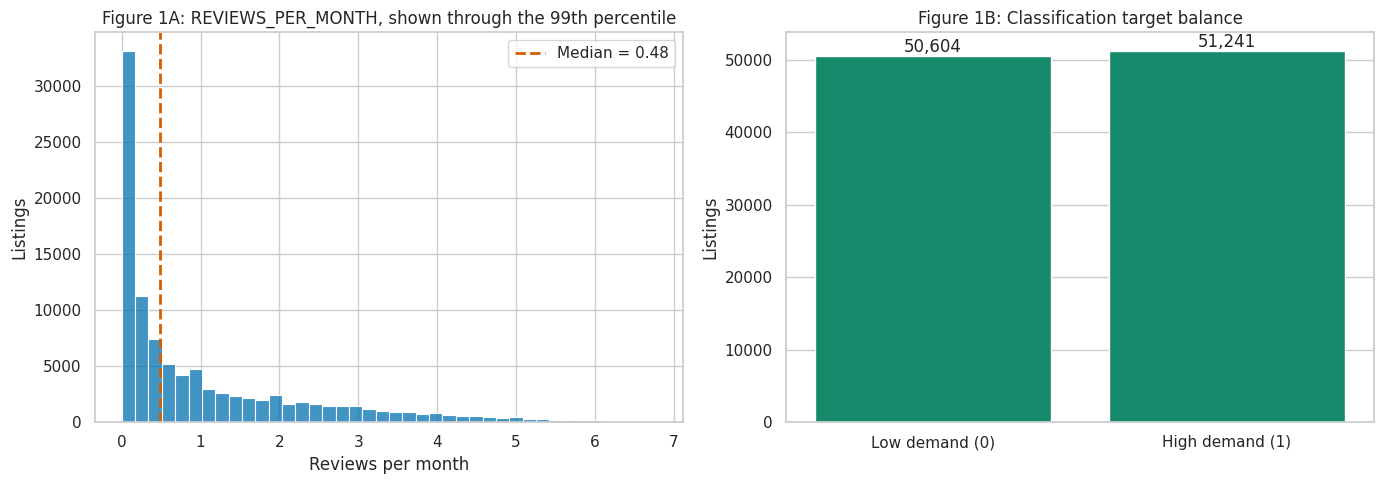

ML insight: REVIEWS_PER_MONTH is right-skewed with skewness 6.97 and 15.4% zero values. Predicting the raw count would require a count or transformed regression model. The median threshold creates a nearly balanced classification target: class 0 has 50,604 listings and class 1 has 51,241. Use stratification and do not impute the target.

In [4]:
median_rpm = df["REVIEWS_PER_MONTH"].median()
target_counts = df[TARGET].value_counts().sort_index()
zero_rate = 100 * (df["REVIEWS_PER_MONTH"] == 0).mean()
rpm_skew = skew(df["REVIEWS_PER_MONTH"], nan_policy="omit")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df.loc[df["REVIEWS_PER_MONTH"] <= df["REVIEWS_PER_MONTH"].quantile(.99), "REVIEWS_PER_MONTH"],
             bins=40, color=BLUE, ax=axes[0])
axes[0].axvline(median_rpm, color=ORANGE, linestyle="--", linewidth=2,
                label=f"Median = {median_rpm:.2f}")
axes[0].set(title="Figure 1A: REVIEWS_PER_MONTH, shown through the 99th percentile",
            xlabel="Reviews per month", ylabel="Listings")
axes[0].legend()

sns.barplot(x=["Low demand (0)", "High demand (1)"],
            y=[target_counts.get(0, 0), target_counts.get(1, 0)],
            color=GREEN, ax=axes[1])
axes[1].set(title="Figure 1B: Classification target balance", xlabel="", ylabel="Listings")
for i, value in enumerate([target_counts.get(0, 0), target_counts.get(1, 0)]):
    axes[1].text(i, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

display(Markdown(f'''ML insight: REVIEWS_PER_MONTH is right-skewed with skewness {rpm_skew:.2f} and {zero_rate:.1f}% zero values. Predicting the raw count would require a count or transformed regression model. The median threshold creates a nearly balanced classification target: class 0 has {target_counts.get(0, 0):,} listings and class 1 has {target_counts.get(1, 0):,}. Use stratification and do not impute the target.'''))


## 3. Predictor shape, skewness, and outliers

Lecture 5 emphasizes using histograms and distribution summaries before choosing transformations. The following figure focuses on candidate predictors whose shapes can affect a linear model.


,FEATURE,SKEWNESS,MEDIAN,P99,MAX
0,PRICE,0.001,624.0,1188.0,1200.0
1,MINIMUM_NIGHTS,10.262,3.0,45.0,365.0
2,NUMBER_OF_REVIEWS,3.841,7.0,232.0,1024.0
3,CALCULATED_HOST_LISTINGS_COUNT,7.225,1.0,186.0,332.0
4,AVAILABILITY_365,0.535,90.0,365.0,365.0


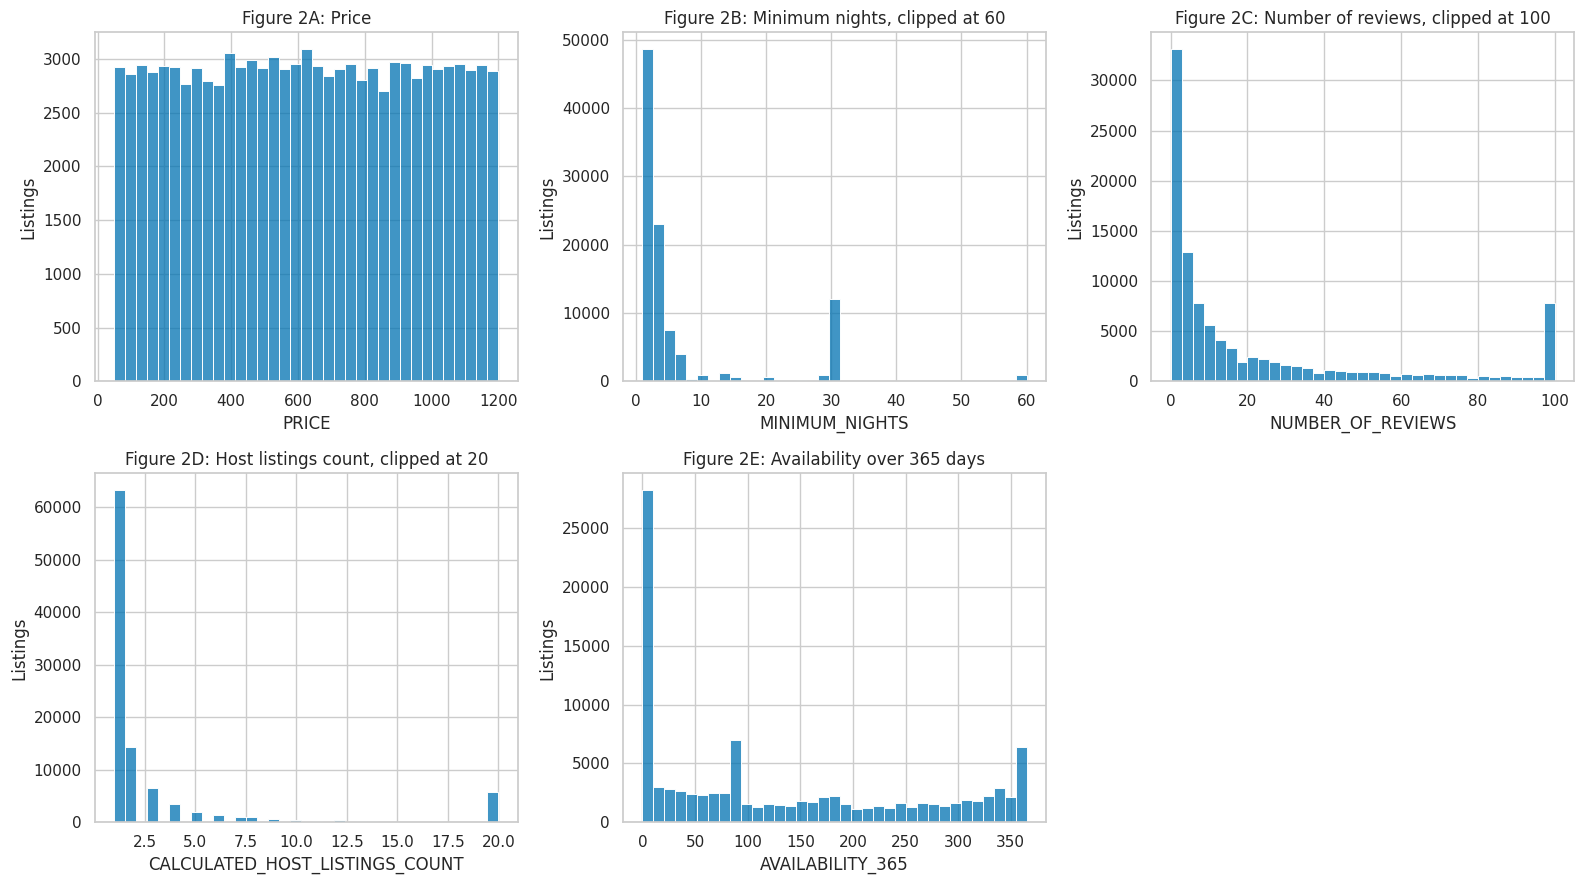

ML insight: the most skewed candidate is MINIMUM_NIGHTS with skewness 10.26. A linear model should use a robust or log transformation for highly skewed operational counts. A tree model can use the original values, but the extreme tail still needs validation so a few listings do not dominate splits. NUMBER_OF_REVIEWS is especially important because it is both skewed and target-adjacent.

In [5]:
shape_cols = ["PRICE", "MINIMUM_NIGHTS", "NUMBER_OF_REVIEWS",
              "CALCULATED_HOST_LISTINGS_COUNT", "AVAILABILITY_365"]
shape_rows = []
for col in shape_cols:
    values = df[col].dropna()
    shape_rows.append({
        "FEATURE": col,
        "SKEWNESS": skew(values, nan_policy="omit"),
        "MEDIAN": values.median(),
        "P99": values.quantile(.99),
        "MAX": values.max(),
    })
shape_summary = pd.DataFrame(shape_rows)
display(shape_summary.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("PRICE", None, "Figure 2A: Price"),
    ("MINIMUM_NIGHTS", 60, "Figure 2B: Minimum nights, clipped at 60"),
    ("NUMBER_OF_REVIEWS", 100, "Figure 2C: Number of reviews, clipped at 100"),
    ("CALCULATED_HOST_LISTINGS_COUNT", 20, "Figure 2D: Host listings count, clipped at 20"),
    ("AVAILABILITY_365", None, "Figure 2E: Availability over 365 days"),
]
for ax, (col, upper, title) in zip(axes.flat, plot_specs):
    values = df[col]
    if upper is not None:
        values = values.clip(upper=upper)
    sns.histplot(values, bins=35, color=BLUE, ax=ax)
    ax.set(title=title, xlabel=col, ylabel="Listings")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

most_skewed = shape_summary.iloc[shape_summary["SKEWNESS"].abs().argmax()]
display(Markdown(f'''ML insight: the most skewed candidate is {most_skewed['FEATURE']} with skewness {most_skewed['SKEWNESS']:.2f}. A linear model should use a robust or log transformation for highly skewed operational counts. A tree model can use the original values, but the extreme tail still needs validation so a few listings do not dominate splits. NUMBER_OF_REVIEWS is especially important because it is both skewed and target-adjacent.'''))


## 4. Bivariate analysis: price deciles and the demand label

Instead of treating price as a target, this analysis tests whether price contributes useful signal for the demand classifier. Deciles preserve the observed distribution without imposing equal-dollar groups.


,PRICE_DECILE,LISTINGS,HIGH_DEMAND_RATE,MEDIAN_RPM
0,"(49.999, 165.0]",10241,49.624,0.46
1,"(165.0, 281.0]",10157,50.162,0.48
2,"(281.0, 399.0]",10204,49.392,0.46
3,"(399.0, 511.0]",10167,51.166,0.50
4,"(511.0, 624.0]",10174,51.661,0.52
5,"(624.0, 738.0]",10234,50.078,0.48
6,"(738.0, 855.0]",10125,50.548,0.48
7,"(855.0, 971.0]",10245,50.239,0.48
8,"(971.0, 1086.0]",10229,49.878,0.47
9,"(1086.0, 1200.0]",10069,50.392,0.49


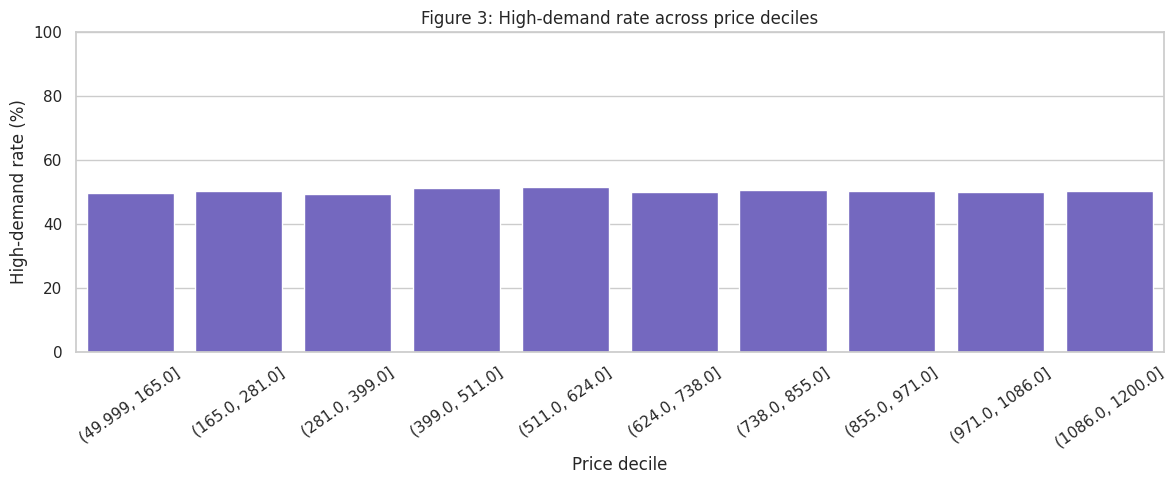

ML insight: high-demand rates differ by only 2.3 percentage points across price deciles, and Spearman correlation between price and reviews/month is 0.005. Keep PRICE as a control feature, but expect location, availability, and stay rules to provide more useful signal. Do not select price as the target for this demand task.

In [6]:
df["PRICE_DECILE"] = pd.qcut(df["PRICE"], q=10, duplicates="drop")
price_decile = (df.groupby("PRICE_DECILE", observed=False)
                .agg(LISTINGS=(TARGET, "size"),
                     HIGH_DEMAND_RATE=(TARGET, "mean"),
                     MEDIAN_RPM=("REVIEWS_PER_MONTH", "median"))
                .reset_index())
price_decile["HIGH_DEMAND_RATE"] *= 100
display(price_decile.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=price_decile, x="PRICE_DECILE", y="HIGH_DEMAND_RATE", color=PURPLE, ax=ax)
ax.set(title="Figure 3: High-demand rate across price deciles",
       xlabel="Price decile", ylabel="High-demand rate (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

price_rate_gap = price_decile["HIGH_DEMAND_RATE"].max() - price_decile["HIGH_DEMAND_RATE"].min()
price_spearman = df[["PRICE", "REVIEWS_PER_MONTH"]].corr(method="spearman").iloc[0, 1]
display(Markdown(f'''ML insight: high-demand rates differ by only {price_rate_gap:.1f} percentage points across price deciles, and Spearman correlation between price and reviews/month is {price_spearman:.3f}. Keep PRICE as a control feature, but expect location, availability, and stay rules to provide more useful signal. Do not select price as the target for this demand task.'''))


## 5. Multivariate analysis: minimum nights × availability

A one-variable chart can hide interactions. This heatmap tests whether the demand label changes differently when stay restrictions and availability are considered together.


AVAILABILITY_BIN,0-30,31-90,91-180,181-270,271-365
MIN_NIGHTS_BIN,,,,,
1,42.9,63.5,67.4,64.0,67.4
2-3,43.0,69.3,73.9,71.5,70.2
4-7,26.4,48.4,56.3,50.7,52.1
8-14,19.7,27.8,28.1,28.8,24.8
15-30,25.9,30.5,30.1,27.6,20.6
31+,23.5,22.2,22.3,30.4,17.3


AVAILABILITY_BIN,0-30,31-90,91-180,181-270,271-365
MIN_NIGHTS_BIN,,,,,
1,7663,5018,3951,2502,6096
2-3,14464,7775,5914,4480,7272
4-7,7508,3327,2484,2006,2808
8-14,1184,522,331,292,399
15-30,2700,2203,1902,2281,5114
31+,298,288,273,276,514


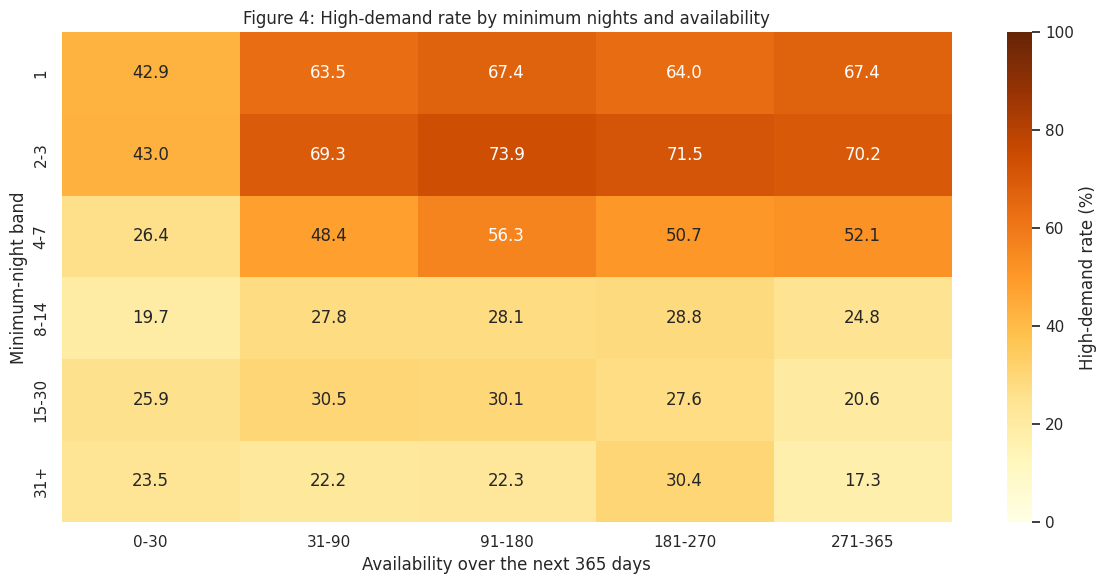

ML insight: the interaction table contains observed high-demand rates from 17.3% to 73.9% across valid cells. This spread is larger than the price-decile spread, so a model should allow non-linear effects and interactions. Random forest or gradient boosting is a better first non-linear test than a purely additive linear model.

In [7]:
min_bins = [0, 1, 3, 7, 14, 30, np.inf]
min_labels = ["1", "2-3", "4-7", "8-14", "15-30", "31+"]
availability_bins = [-1, 30, 90, 180, 270, 365]
availability_labels = ["0-30", "31-90", "91-180", "181-270", "271-365"]

df["MIN_NIGHTS_BIN"] = pd.cut(df["MINIMUM_NIGHTS"].clip(lower=1),
                              bins=min_bins, labels=min_labels, include_lowest=True)
df["AVAILABILITY_BIN"] = pd.cut(df["AVAILABILITY_365"],
                                bins=availability_bins, labels=availability_labels, include_lowest=True)

min_availability = (df.pivot_table(index="MIN_NIGHTS_BIN", columns="AVAILABILITY_BIN",
                                   values=TARGET, aggfunc="mean", observed=False) * 100)
min_availability_counts = df.pivot_table(index="MIN_NIGHTS_BIN", columns="AVAILABILITY_BIN",
                                         values=TARGET, aggfunc="size", observed=False)
display(min_availability.round(1))
display(min_availability_counts)

plt.figure(figsize=(12, 6))
sns.heatmap(min_availability, annot=True, fmt=".1f", cmap="YlOrBr",
            vmin=0, vmax=100, cbar_kws={"label": "High-demand rate (%)"})
plt.title("Figure 4: High-demand rate by minimum nights and availability")
plt.xlabel("Availability over the next 365 days")
plt.ylabel("Minimum-night band")
plt.tight_layout()
plt.show()

valid_cells = min_availability.stack().dropna()
display(Markdown(f'''ML insight: the interaction table contains observed high-demand rates from {valid_cells.min():.1f}% to {valid_cells.max():.1f}% across valid cells. This spread is larger than the price-decile spread, so a model should allow non-linear effects and interactions. Random forest or gradient boosting is a better first non-linear test than a purely additive linear model.'''))


## 6. Multivariate analysis: host scale × room type

This figure tests whether the effect of host scale depends on the type of room being offered. It also exposes small cells that should not be over-interpreted.


ROOM_TYPE,Entire home/apt,Hotel room,Private room,Shared room
HOST_TYPE,,,,
Single,49.9,73.7,39.7,34.1
Small (2-5),64.7,75.0,65.1,57.8
Multi (6+),27.9,55.0,57.6,61.5


ROOM_TYPE,Entire home/apt,Hotel room,Private room,Shared room
HOST_TYPE,,,,
Single,37884,19,24568,824
Small (2-5),9325,16,16272,756
Multi (6+),6131,80,5342,628


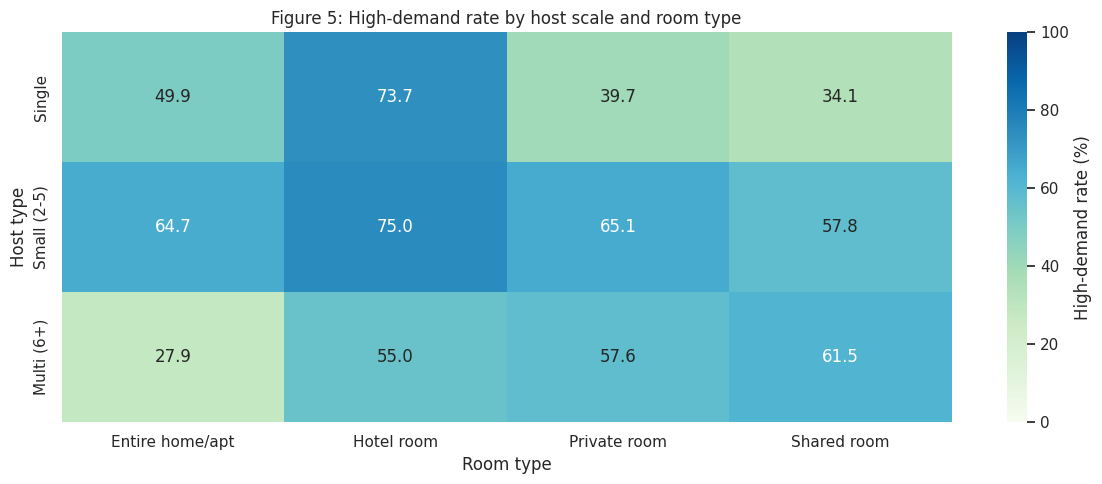

ML insight: the host-scale/room-type cells range from 27.9% to 75.0%, but the smallest cell contains only 16 listings. Include host and room type as categorical predictors, but inspect cell counts and consider regularization or tree-based interactions rather than treating every cell as equally reliable.

In [8]:
host_order = ["Single", "Small (2-5)", "Multi (6+)"]
df["HOST_TYPE"] = pd.Categorical(df["HOST_TYPE"], categories=host_order, ordered=True)
host_room_rate = (df.pivot_table(index="HOST_TYPE", columns="ROOM_TYPE",
                                  values=TARGET, aggfunc="mean", observed=False) * 100)
host_room_n = df.pivot_table(index="HOST_TYPE", columns="ROOM_TYPE",
                             values=TARGET, aggfunc="size", observed=False)
display(host_room_rate.round(1))
display(host_room_n)

plt.figure(figsize=(12, 5))
sns.heatmap(host_room_rate, annot=True, fmt=".1f", cmap="GnBu",
            vmin=0, vmax=100, cbar_kws={"label": "High-demand rate (%)"})
plt.title("Figure 5: High-demand rate by host scale and room type")
plt.xlabel("Room type")
plt.ylabel("Host type")
plt.tight_layout()
plt.show()

smallest_cell = int(host_room_n.min().min())
largest_cell_rate = host_room_rate.stack().max()
smallest_cell_rate = host_room_rate.stack().min()
display(Markdown(f'''ML insight: the host-scale/room-type cells range from {smallest_cell_rate:.1f}% to {largest_cell_rate:.1f}%, but the smallest cell contains only {smallest_cell:,} listings. Include host and room type as categorical predictors, but inspect cell counts and consider regularization or tree-based interactions rather than treating every cell as equally reliable.'''))


## 7. Neighborhood reliability and rare-category handling

Neighborhood is potentially predictive, but a high-cardinality categorical feature can overfit when some levels have very few listings. The chart ranks the 15 largest neighborhoods and displays an approximate 95% binomial interval.


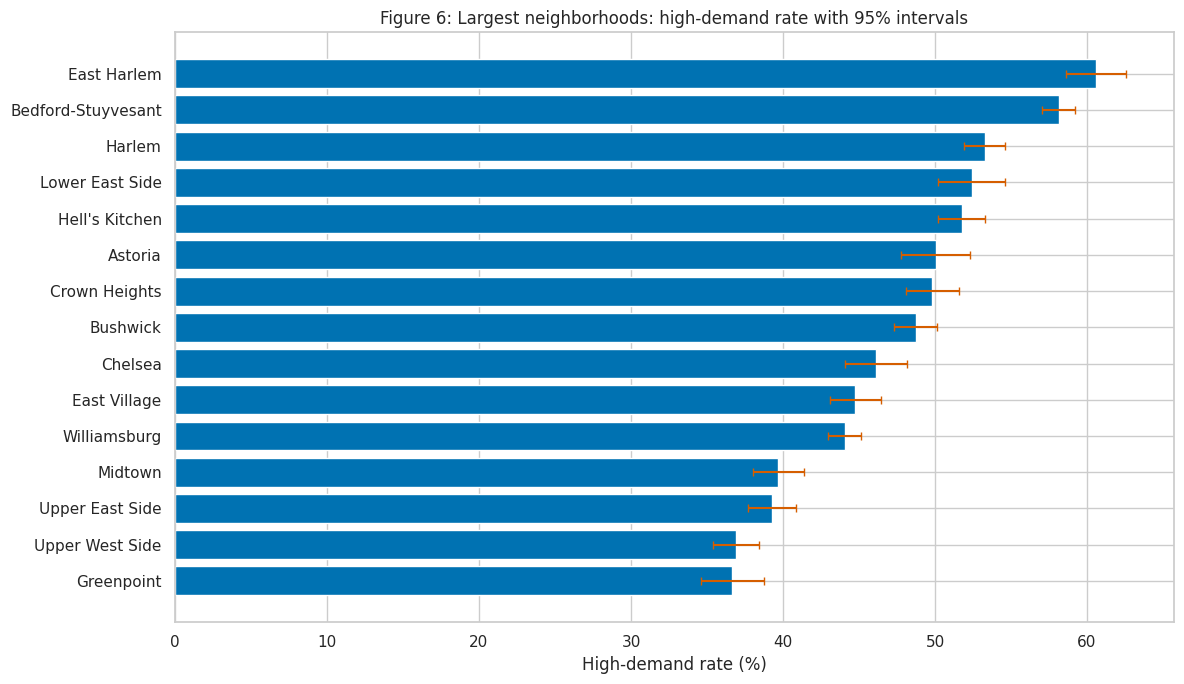

ML insight: the dataset contains 224 neighborhoods; 69 have fewer than 30 listings, covering 999 rows. Use one-hot encoding with a rare-category rule such as grouping levels below 30 listings into Other, and use stratified validation so the model is not judged by a single rare neighborhood.

In [9]:
def wilson_interval(successes, total, z=1.96):
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2*total)) / denom
    half = z * np.sqrt((p*(1-p) + z**2/(4*total)) / total) / denom
    return center - half, center + half

neighborhood_summary = (df.groupby("NEIGHBOURHOOD", observed=False)
                        .agg(LISTINGS=(TARGET, "size"),
                             HIGH_DEMAND=(TARGET, "sum"),
                             HIGH_DEMAND_RATE=(TARGET, "mean"))
                        .reset_index())
neighborhood_summary["LOWER"], neighborhood_summary["UPPER"] = zip(*[
    wilson_interval(row.HIGH_DEMAND, row.LISTINGS)
    for row in neighborhood_summary.itertuples()
])
neighborhood_summary["HIGH_DEMAND_RATE"] *= 100
neighborhood_summary["LOWER"] *= 100
neighborhood_summary["UPPER"] *= 100
top_neighborhoods = neighborhood_summary.nlargest(15, "LISTINGS").sort_values("HIGH_DEMAND_RATE")

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(top_neighborhoods))
ax.barh(y, top_neighborhoods["HIGH_DEMAND_RATE"], color=BLUE)
ax.errorbar(top_neighborhoods["HIGH_DEMAND_RATE"], y,
            xerr=[top_neighborhoods["HIGH_DEMAND_RATE"] - top_neighborhoods["LOWER"],
                  top_neighborhoods["UPPER"] - top_neighborhoods["HIGH_DEMAND_RATE"]],
            fmt="none", ecolor=ORANGE, capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(top_neighborhoods["NEIGHBOURHOOD"])
ax.set_xlabel("High-demand rate (%)")
ax.set_title("Figure 6: Largest neighborhoods: high-demand rate with 95% intervals")
plt.tight_layout()
plt.show()

neighborhood_counts = df["NEIGHBOURHOOD"].value_counts()
rare_neighborhoods = int((neighborhood_counts < 30).sum())
rare_rows = int(neighborhood_counts[neighborhood_counts < 30].sum())
display(Markdown(f'''ML insight: the dataset contains {df['NEIGHBOURHOOD'].nunique():,} neighborhoods; {rare_neighborhoods} have fewer than 30 listings, covering {rare_rows:,} rows. Use one-hot encoding with a rare-category rule such as grouping levels below 30 listings into Other, and use stratified validation so the model is not judged by a single rare neighborhood.'''))


## 8. Feature redundancy and leakage screening

The final EDA decision must distinguish a strong predictor from a field that simply restates the target. The chart uses Spearman correlation with the continuous demand proxy, not with the binary label alone.


,FEATURE,SPEARMAN_WITH_RPM
4,MINIMUM_NIGHTS,-0.268
5,LAT,-0.052
7,CONSTRUCTION_YEAR,0.002
6,PRICE,0.005
3,CALCULATED_HOST_LISTINGS_COUNT,0.108
2,LONG,0.121
1,AVAILABILITY_365,0.164
0,NUMBER_OF_REVIEWS,0.843


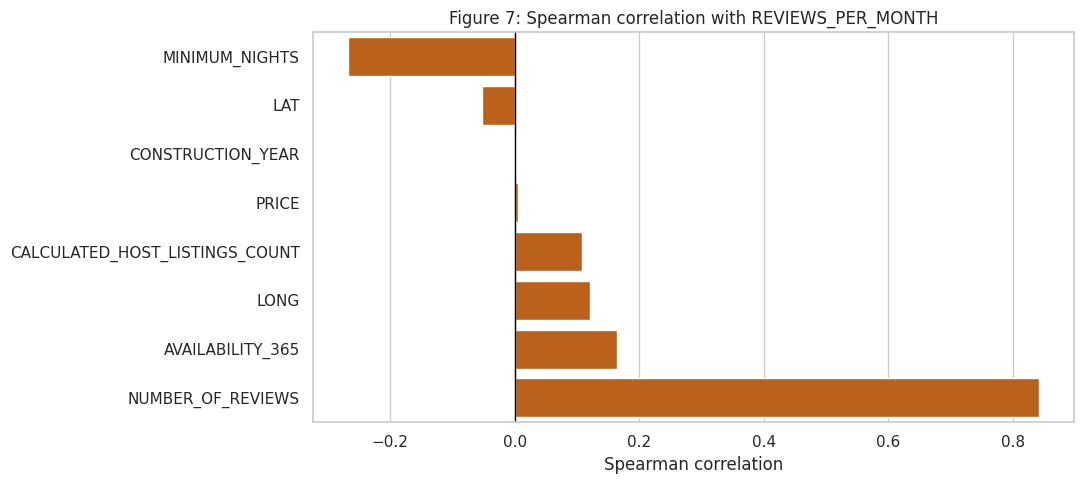

ML insight: NUMBER_OF_REVIEWS has correlation 0.843 with reviews/month, far larger than the operational predictors. It is accumulated demand information, so the primary future-demand model should exclude it. MINIMUM_NIGHTS has correlation -0.268, which supports keeping it as a genuine listing characteristic rather than treating it as leakage.

In [10]:
corr_cols = ["NUMBER_OF_REVIEWS", "AVAILABILITY_365", "LONG",
              "CALCULATED_HOST_LISTINGS_COUNT", "MINIMUM_NIGHTS",
              "LAT", "PRICE", "CONSTRUCTION_YEAR"]
corr_rows = []
for col in corr_cols:
    corr_rows.append({
        "FEATURE": col,
        "SPEARMAN_WITH_RPM": df[[col, "REVIEWS_PER_MONTH"]].corr(method="spearman").iloc[0, 1]
    })
corr_summary = pd.DataFrame(corr_rows).sort_values("SPEARMAN_WITH_RPM")
display(corr_summary.round(3))

plt.figure(figsize=(11, 5))
sns.barplot(data=corr_summary, x="SPEARMAN_WITH_RPM", y="FEATURE", color=ORANGE)
plt.axvline(0, color="black", linewidth=1)
plt.title("Figure 7: Spearman correlation with REVIEWS_PER_MONTH")
plt.xlabel("Spearman correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

review_corr = df[["NUMBER_OF_REVIEWS", "REVIEWS_PER_MONTH"]].corr(method="spearman").iloc[0, 1]
min_corr = df[["MINIMUM_NIGHTS", "REVIEWS_PER_MONTH"]].corr(method="spearman").iloc[0, 1]
display(Markdown(f'''ML insight: NUMBER_OF_REVIEWS has correlation {review_corr:.3f} with reviews/month, far larger than the operational predictors. It is accumulated demand information, so the primary future-demand model should exclude it. MINIMUM_NIGHTS has correlation {min_corr:.3f}, which supports keeping it as a genuine listing characteristic rather than treating it as leakage.'''))


## 9. Model-ready feature policy

The figures support the following primary ML direction:

- Binary classification target: HIGH_DEMAND
- Stratified 80/20 split for the first baseline
- Logistic regression as an interpretable baseline
- Random forest or gradient boosting for non-linear and interaction effects
- Exclude target-derived and target-adjacent review fields from the future-demand model
- Compare F1, recall, precision, and ROC-AUC
- Group rare neighborhood levels before one-hot encoding


In [11]:
target = "HIGH_DEMAND"
drop_primary = [
    "HIGH_DEMAND", "REVIEWS_PER_MONTH", "LOG_REVIEWS_PER_MONTH",
    "NUMBER_OF_REVIEWS", "ID", "HOST_ID", "NAME", "HOST_NAME",
    "SERVICE_FEE"
]
numeric_features = [
    "LAT", "LONG", "CONSTRUCTION_YEAR", "PRICE",
    "MINIMUM_NIGHTS", "CALCULATED_HOST_LISTINGS_COUNT", "AVAILABILITY_365"
]
categorical_features = [
    "NEIGHBOURHOOD_GROUP", "NEIGHBOURHOOD", "HOST_IDENTITY_VERIFIED",
    "INSTANT_BOOKABLE", "CANCELLATION_POLICY", "ROOM_TYPE", "HOST_TYPE"
]
feature_policy = pd.DataFrame({
    "TARGET": [target],
    "PRIMARY_EXCLUSIONS": [", ".join(drop_primary)],
    "NUMERIC_FEATURES": [", ".join(numeric_features)],
    "CATEGORICAL_FEATURES": [", ".join(categorical_features)]
})
display(feature_policy.T.rename(columns={0: "Decision"}))


,Decision
TARGET,HIGH_DEMAND
PRIMARY_EXCLUSIONS,"HIGH_DEMAND, REVIEWS_PER_MONTH, LOG_REVIEWS_PE..."
NUMERIC_FEATURES,"LAT, LONG, CONSTRUCTION_YEAR, PRICE, MINIMUM_N..."
CATEGORICAL_FEATURES,"NEIGHBOURHOOD_GROUP, NEIGHBOURHOOD, HOST_IDENT..."


## Decision table

Each Because entry links the decision to a measured count, percentage, statistic, valid range, or EDA figure. Another developer should be able to prepare the primary future-demand dataset by following this table.


In [12]:
service_ratio = df["SERVICE_FEE"] / df["PRICE"]
price_rate_gap = price_decile["HIGH_DEMAND_RATE"].max() - price_decile["HIGH_DEMAND_RATE"].min()
min_rates = df.groupby("MIN_NIGHTS_BIN", observed=False)[TARGET].mean() * 100
availability_rates = df.groupby("AVAILABILITY_BIN", observed=False)[TARGET].mean() * 100
host_rates = df.groupby("HOST_TYPE", observed=False)[TARGET].mean() * 100
min_rate_low, min_rate_high = min_rates.min(), min_rates.max()
availability_rate_low, availability_rate_high = availability_rates.min(), availability_rates.max()
host_rate_low, host_rate_high = host_rates.min(), host_rates.max()

decision_rows = [
    ["1", "HIGH_DEMAND target", "Use as the binary classification target; do not impute it.",
     f"The target has {target_counts.get(0,0):,} class-0 rows and {target_counts.get(1,0):,} class-1 rows after the median threshold, so the classes are close to balanced (Figure 1)."],
    ["2", "REVIEWS_PER_MONTH", "Use only to define HIGH_DEMAND; exclude from X.",
     f"It directly defines the target and is right-skewed with skewness {rpm_skew:.2f}; using it as an input would expose the answer."],
    ["3", "LOG_REVIEWS_PER_MONTH", "Exclude from X.",
     "It is a transformation of the target-generating field and therefore carries the same leakage risk."],
    ["4", "NUMBER_OF_REVIEWS", "Exclude from the primary future-demand model; use only as a separate descriptive benchmark.",
     f"Its Spearman correlation with REVIEWS_PER_MONTH is {review_corr:.3f}, making it accumulated demand information rather than a clean pre-demand listing attribute (Figure 7)."],
    ["5", "ID and HOST_ID", "Drop from the primary feature matrix.",
     f"ID has {df['ID'].nunique():,} unique values for {len(df):,} rows and HOST_ID has only {len(df)-df['HOST_ID'].nunique():,} repeated row(s); identifiers do not generalize."],
    ["6", "NAME and HOST_NAME", "Drop unless a separate NLP experiment is approved.",
     f"NAME has {df['NAME'].nunique():,} unique values and HOST_NAME has {df['HOST_NAME'].nunique():,}; high-cardinality text would require a separate text feature design."],
    ["7", "NEIGHBOURHOOD_GROUP and NEIGHBOURHOOD", "Keep as categorical predictors; group neighborhoods with fewer than 30 listings into Other.",
     f"There are {df['NEIGHBOURHOOD'].nunique():,} neighborhoods and {rare_neighborhoods} have fewer than 30 listings, affecting {rare_rows:,} rows (Figure 6)."],
    ["8", "LAT and LONG", "Keep as numeric location predictors.",
     f"LAT ranges from {df['LAT'].min():.2f} to {df['LAT'].max():.2f} and LONG ranges from {df['LONG'].min():.2f} to {df['LONG'].max():.2f}; retain the coordinates initially and compare them with neighborhood encodings during validation."],
    ["9", "MINIMUM_NIGHTS", "Keep; use bins, log1p, or a non-linear model.",
     f"The feature has skewness {skew(df['MINIMUM_NIGHTS']):.2f} and high-demand rates range from {min_rate_low:.1f}% to {min_rate_high:.1f}% across bands (Figures 2 and 4)."],
    ["10", "AVAILABILITY_365", "Keep; allow non-linear and interaction effects.",
     f"High-demand rates range from {availability_rate_low:.1f}% to {availability_rate_high:.1f}% across availability bands, and the minimum-night interaction heatmap changes across cells (Figure 4)."],
    ["11", "CALCULATED_HOST_LISTINGS_COUNT", "Keep as log1p or use HOST_TYPE; avoid relying only on the raw scale.",
     f"Its skewness is {skew(df['CALCULATED_HOST_LISTINGS_COUNT']):.2f}, so the raw tail is highly uneven. HOST_TYPE rates range from {host_rate_low:.1f}% to {host_rate_high:.1f}% (Figures 2 and 5)."],
    ["12", "HOST_TYPE and ROOM_TYPE", "Keep as categorical predictors; test their interaction with regularization or a tree model.",
     "The host-scale/room-type heatmap shows different demand rates across combinations, but cell counts must be checked before interpreting small groups (Figure 5)."],
    ["13", "PRICE", "Keep as a control predictor; do not use as the target.",
     f"Price decile high-demand rates differ by only {price_rate_gap:.1f} percentage points and price-to-RPM Spearman correlation is {price_spearman:.3f} (Figure 3)."],
    ["14", "SERVICE_FEE", "Drop when PRICE is retained.",
     f"SERVICE_FEE / PRICE has mean {service_ratio.mean():.3f} and standard deviation {service_ratio.std():.4f}, so it is near-duplicate pricing information."],
    ["15", "CONSTRUCTION_YEAR", "Keep initially as a low-priority numeric control.",
     f"Values are bounded from {df['CONSTRUCTION_YEAR'].min():.0f} to {df['CONSTRUCTION_YEAR'].max():.0f}; its RPM correlation is small, so the model can test incremental signal."],
    ["16", "Missing values and duplicate rows", "Do not add further row deletion or imputation to this cleaned file; retain validation checks in the pipeline.",
     f"The supplied cleaned CSV has {int(df.isna().sum().sum()):,} missing cells and {int(df.duplicated().sum()):,} duplicate rows at EDA entry."],
]
decision_table = pd.DataFrame(decision_rows, columns=["S.No.", "Column / issue", "Decision", "Because"])
display(decision_table)
decision_table.to_csv("Aryan_Mittal_decision_table.csv", index=False)


,S.No.,Column / issue,Decision,Because
0,1,HIGH_DEMAND target,Use as the binary classification target; do no...,"The target has 50,604 class-0 rows and 51,241 ..."
1,2,REVIEWS_PER_MONTH,Use only to define HIGH_DEMAND; exclude from X.,It directly defines the target and is right-sk...
2,3,LOG_REVIEWS_PER_MONTH,Exclude from X.,It is a transformation of the target-generatin...
3,4,NUMBER_OF_REVIEWS,Exclude from the primary future-demand model; ...,Its Spearman correlation with REVIEWS_PER_MONT...
4,5,ID and HOST_ID,Drop from the primary feature matrix.,"ID has 101,845 unique values for 101,845 rows ..."
5,6,NAME and HOST_NAME,Drop unless a separate NLP experiment is appro...,"NAME has 61,174 unique values and HOST_NAME ha..."
6,7,NEIGHBOURHOOD_GROUP and NEIGHBOURHOOD,Keep as categorical predictors; group neighbor...,There are 224 neighborhoods and 69 have fewer ...
7,8,LAT and LONG,Keep as numeric location predictors.,LAT ranges from 40.50 to 40.92 and LONG ranges...
8,9,MINIMUM_NIGHTS,"Keep; use bins, log1p, or a non-linear model.",The feature has skewness 10.26 and high-demand...
9,10,AVAILABILITY_365,Keep; allow non-linear and interaction effects.,High-demand rates range from 36.9% to 61.6% ac...


## Final modeling handoff

The primary future-demand dataset should use listing characteristics available before demand accumulates. The recommended first comparison is a stratified logistic-regression baseline versus a random forest or gradient-boosting model. Report F1, recall, precision, and ROC-AUC, then check performance by borough, room type, and host type. A separate current-state benchmark may include NUMBER_OF_REVIEWS, but it must be labeled target-adjacent and should not replace the primary future-demand analysis.
